In [ ]:
import pandas as pd
import folium
from folium.plugins import BeautifyIcon
import webbrowser
import os
import numpy as np
from folium import FeatureGroup, LayerControl
import matplotlib.pyplot as plt


In [202]:
nodes_final = pd.read_excel("danish_grid_graph_ready.xlsx", sheet_name="nodes")
edges_final = pd.read_excel("danish_grid_graph_ready.xlsx", sheet_name="edges")

### Nodes that have the same lon and lat will be move alightly appart so that were able to see the connections between them.

In [203]:
def jitter_coordinates(df, lat_col="lat", lon_col="lon", strength=0.001):
    df = df.copy()

    dup_mask = df.duplicated(subset=[lat_col, lon_col], keep=False)

    # Gaussian noise (natural spread)
    df.loc[dup_mask, "lat_jitter"] = (
        df.loc[dup_mask, lat_col] + np.random.normal(0, strength, size=dup_mask.sum())
    )
    df.loc[dup_mask, "lon_jitter"] = (
        df.loc[dup_mask, lon_col] + np.random.normal(0, strength, size=dup_mask.sum())
    )

    # keep original for others
    df.loc[~dup_mask, "lat_jitter"] = df.loc[~dup_mask, lat_col]
    df.loc[~dup_mask, "lon_jitter"] = df.loc[~dup_mask, lon_col]

    return df

In [204]:
nodes_plot = jitter_coordinates(nodes_final, strength=0.01)
m = folium.Map(location=[56.2, 10.0], zoom_start=7, tiles="CartoDB Positron")

### Function to get specific colours for specific nodes

In [205]:
def get_node_style(row):
    name = str(row["name"]).lower()
    voltage = row["voltage_kv"]

    if "hvdc" in name:
        return "grey", "circle"
    if "windoff" in name or "havmølle" in name:
        return "grey", "circle"
    if "værket" in name:
        return "grey", "star"

    if pd.notna(voltage):
        if voltage >= 300:
            return "grey", "circle"
        elif voltage >= 200:
            return "grey", "circle"

    return "grey", "circle"

### Adding layers for intaractions on the map

In [206]:

stars_layer = FeatureGroup(name="Power plants (stars)")
nodes_layer = FeatureGroup(name="Substations")
edges_layer = FeatureGroup(name="Transmission lines")


for _, row in nodes_plot.iterrows():
    if pd.notna(row["lat_jitter"]) and pd.notna(row["lon_jitter"]):

        color, shape = get_node_style(row)

        popup_text = f"""
        <b>{row['name']}</b><br>
        Voltage: {row['voltage_kv']} kV<br>
        Supply: {row['supply']:.1f} MW<br>
        Demand: {row['demand']:.1f} MW<br>
        Source: {row['source']}
        """

        if shape == "star":
            folium.Marker(
                location=[row["lat_jitter"], row["lon_jitter"]],
                icon=folium.Icon(
                    icon="bolt",
                    prefix="fa",     # Font Awesome
                    color="black"
                ),
                popup=folium.Popup(popup_text, max_width=300)
            ).add_to(stars_layer)
        else:
            folium.CircleMarker(
                location=[row["lat_jitter"], row["lon_jitter"]],
                radius=4,
                color=color,
                fill=True,
                fill_opacity=0.8,
                popup=folium.Popup(popup_text, max_width=300)
            ).add_to(nodes_layer)


### Function to get specific colours for specific edges

In [207]:
def get_edge_style(row):
    voltage = row.get("voltage_kv", None)
    line_type = str(row.get("line_type", "")).lower()
    edge_type = row.get("edge_type", "")

    if edge_type == "hvdc":
        return "grey", "5,5"

    is_cable = "cable" in line_type

    if pd.notna(voltage):
        if voltage >= 300:
            return ("grey", "5,5") if is_cable else ("grey", None)
        elif voltage >= 200:
            return ("grey", "5,5") if is_cable else ("grey", None)
        else:
            return ("grey", "5,5") if is_cable else ("grey", None)

    return "gray", None


for _, row in edges_final.iterrows():
    n1 = nodes_plot[nodes_plot["bus_index"] == row["node1"]]
    n2 = nodes_plot[nodes_plot["bus_index"] == row["node2"]]

    if len(n1) > 0 and len(n2) > 0:
        latlon1 = n1.iloc[0][["lat_jitter", "lon_jitter"]]
        latlon2 = n2.iloc[0][["lat_jitter", "lon_jitter"]]

        if pd.notna(latlon1["lat_jitter"]) and pd.notna(latlon2["lat_jitter"]):

            color, dash = get_edge_style(row)

            folium.PolyLine(
                locations=[
                    [latlon1["lat_jitter"], latlon1["lon_jitter"]],
                    [latlon2["lat_jitter"], latlon2["lon_jitter"]]
                ],
                color=color,
                weight=2,
                opacity=0.7,
                dash_array=dash
            ).add_to(edges_layer)

stars_layer.add_to(m)
nodes_layer.add_to(m)
edges_layer.add_to(m)


### saving the map and redering in html

In [208]:
m.save("danish_grid_map.html")
webbrowser.open("file://" + os.path.realpath("danish_grid_map.html"))

True

# Interpreting the results 


### Load + aggregate by node

In [209]:
results = pd.read_excel("scenario_results.xlsx")

top5 = (
    results
    .groupby("name")
    .agg({
        "total_unmet_demand_MW": "max",
        "total_oversupply_MW": "max",
        "num_groups": "max"
    })
    .reset_index()
)

### Normalization

In [210]:
def normalize(series):
    if series.max() == series.min():
        return 0  # avoid division by zero
    return (series - series.min()) / (series.max() - series.min())

# -----------------------
# NORMALIZE METRICS
# -----------------------
top5["unmet_norm"] = normalize(top5["total_unmet_demand_MW"])
top5["over_norm"] = normalize(top5["total_oversupply_MW"])
top5["groups_norm"] = normalize(top5["num_groups"])

# -----------------------
# WEIGHTED SCORE
# -----------------------
top5["score"] = (
    0.7 * top5["unmet_norm"] +
    0.2 * top5["over_norm"] +
    0.1 * top5["groups_norm"]
)

### Pulling out the top nodes

In [211]:
top5 = top5.sort_values("score", ascending=False).head(10)

top1_node = top5.iloc[0]["name"].strip().lower()

print("Top 5 critical nodes:")
print(top5[[
    "name",
    "total_unmet_demand_MW",
    "total_oversupply_MW",
    "num_groups",
    "score"
]])

Top 5 critical nodes:
                                                  name  total_unmet_demand_MW  \
309                              400 KV STATION ENDRUP             546.000000   
601                   XED_EE1D - 400 KV STATION ENDRUP             546.000000   
600                                           XED_EE1D             546.000000   
409                HVDC STATION COBRA POL 1 - XED_EE1D             546.000000   
316                             400 KV STATION FRAUGDE             531.791825   
293                     400 KV KOBLINGSSTATION HERSLEV             456.361825   
605          XFG_HK12 - 400 KV KOBLINGSSTATION HERSLEV             456.361825   
425            HVDC STATION STOREBÆLT POL 1 - XFG_HK11             456.361825   
424  HVDC STATION STOREBÆLT POL 1 - HVDC STATION ST...             456.361825   
426            HVDC STATION STOREBÆLT POL 1 - XFG_HK12             456.361825   

     total_oversupply_MW  num_groups     score  
309           514.660800           7 

In [212]:
# Normalize names 
top5_nodes = top5["name"].str.strip().str.lower().tolist()

print("Top 5 critical nodes:")
print(top5[["name", "total_unmet_demand_MW"]])

Top 5 critical nodes:
                                                  name  total_unmet_demand_MW
309                              400 KV STATION ENDRUP             546.000000
601                   XED_EE1D - 400 KV STATION ENDRUP             546.000000
600                                           XED_EE1D             546.000000
409                HVDC STATION COBRA POL 1 - XED_EE1D             546.000000
316                             400 KV STATION FRAUGDE             531.791825
293                     400 KV KOBLINGSSTATION HERSLEV             456.361825
605          XFG_HK12 - 400 KV KOBLINGSSTATION HERSLEV             456.361825
425            HVDC STATION STOREBÆLT POL 1 - XFG_HK11             456.361825
424  HVDC STATION STOREBÆLT POL 1 - HVDC STATION ST...             456.361825
426            HVDC STATION STOREBÆLT POL 1 - XFG_HK12             456.361825


### Creating ne layers of the critical points for the graph

In [213]:
top5_nodes_layer = FeatureGroup(name="Top 5 critical nodes")
top5_edges_layer = FeatureGroup(name="Top 5 affected lines")

### Adding The nodes

In [214]:
for _, row in nodes_plot.iterrows():
    if pd.notna(row["lat_jitter"]) and pd.notna(row["lon_jitter"]):

        is_top5 = row["name"].strip().lower() in top5_nodes

        if is_top5:
            name_key = row["name"].strip().lower()
            if name_key == top1_node:
                # 🔥 MOST CRITICAL NODE
                folium.CircleMarker(
                    location=[row["lat_jitter"], row["lon_jitter"]],
                    radius=12,
                    color="darkred",
                    fill=True,
                    fill_color="darkred",
                    fill_opacity=1.0,
                    popup=folium.Popup(
                        f"<b>⚠ MOST CRITICAL NODE</b><br>{row['name']}",
                        max_width=300
                    )
                ).add_to(top5_nodes_layer)

            else:
                # normal top nodes
                folium.CircleMarker(
                    location=[row["lat_jitter"], row["lon_jitter"]],
                    radius=8,
                    color="red",
                    fill=True,
                    fill_opacity=1.0,
                    popup=folium.Popup(
                        f"<b>CRITICAL NODE</b><br>{row['name']}",
                        max_width=300
                    )
                ).add_to(top5_nodes_layer)


# Adding the edges connected 
for _, row in edges_final.iterrows():
    n1 = nodes_plot[nodes_plot["bus_index"] == row["node1"]]
    n2 = nodes_plot[nodes_plot["bus_index"] == row["node2"]]

    if len(n1) > 0 and len(n2) > 0:
        latlon1 = n1.iloc[0][["lat_jitter", "lon_jitter"]]
        latlon2 = n2.iloc[0][["lat_jitter", "lon_jitter"]]

        if pd.notna(latlon1["lat_jitter"]) and pd.notna(latlon2["lat_jitter"]):

            is_top5_edge = (
                n1.iloc[0]["name"].strip().lower() in top5_nodes
                or n2.iloc[0]["name"].strip().lower() in top5_nodes
            )

            name1 = n1.iloc[0]["name"].strip().lower()
            name2 = n2.iloc[0]["name"].strip().lower()

            # 🔥 Check if this edge touches the MOST critical node
            if name1 == top1_node or name2 == top1_node:
                color = "darkred"
                weight = 6

            # Otherwise: normal critical edge
            elif is_top5_edge:
                color = "red"
                weight = 4

            # Skip non-critical edges
            else:
                continue

            folium.PolyLine(
                locations=[
                    [latlon1["lat_jitter"], latlon1["lon_jitter"]],
                    [latlon2["lat_jitter"], latlon2["lon_jitter"]]
                ],
                color=color,
                weight=weight,
                opacity=1.0
            ).add_to(top5_edges_layer)

### Adding to existing map

In [215]:
stars_layer.add_to(m)
nodes_layer.add_to(m)
edges_layer.add_to(m)

top5_nodes_layer.add_to(m)
top5_edges_layer.add_to(m)

LayerControl().add_to(m)

In [216]:
m.save("danish_grid_map_results.html")
webbrowser.open("file://" + os.path.realpath("danish_grid_map_results.html"))

True

In [217]:
top5[["name"]]


,name
309,400 KV STATION ENDRUP
601,XED_EE1D - 400 KV STATION ENDRUP
600,XED_EE1D
409,HVDC STATION COBRA POL 1 - XED_EE1D
316,400 KV STATION FRAUGDE
293,400 KV KOBLINGSSTATION HERSLEV
605,XFG_HK12 - 400 KV KOBLINGSSTATION HERSLEV
425,HVDC STATION STOREBÆLT POL 1 - XFG_HK11
424,HVDC STATION STOREBÆLT POL 1 - HVDC STATION ST...
426,HVDC STATION STOREBÆLT POL 1 - XFG_HK12


In [218]:
nodes_final[nodes_final["name"].isin(top5["name"])][["name", "lat", "lon"]]

,name,lat,lon
25,XED_EE1D,53.716319,6.901904
127,400 KV KOBLINGSSTATION HERSLEV,55.521729,11.342021
305,400 KV STATION ENDRUP,55.607000,8.398000
321,400 KV STATION FRAUGDE,55.364000,10.496000


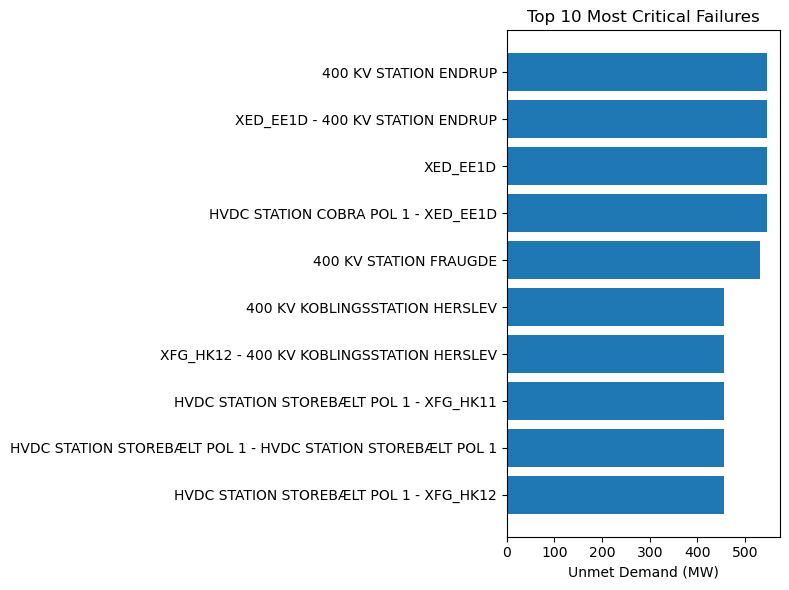

In [ ]:
# Top N
N = 10
topN = top5.sort_values("score", ascending=False).head(N)

plt.figure(figsize=(8, 6))

plt.barh(topN["name"], topN["total_unmet_demand_MW"])

plt.xlabel("Unmet Demand (MW)")
plt.title(f"Top {N} Most Critical Failures")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()